# 01 — Log-Odds + FastText Linguistic Analysis v2

**Fixes from v1:**
- Log-odds was contaminated by Rochester street names and officer names appearing as top differential words
- Now: NER-based proper noun filtering + Rochester geographic stopwords
- FastText nearest-neighbors analysis (semantic space structure)
- UMAP + clustering (proper visualization)

In [1]:
import sys
sys.path.insert(0, '../../notebooks')
import config

import json
import re
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Ready.')

Ready.


## 1. Load Data

In [2]:
# Try clean data first, fall back to BW dataset
import os
if os.path.exists(config.CLEAN_DATA):
    with open(config.CLEAN_DATA) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print(f'Loaded clean data: {len(df)} records')
else:
    with open(config.BW_DATASET) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df = df[df['race'].isin(['Black','White'])].copy()
    print(f'Loaded BW dataset: {len(df)} records')

nar_col = 'narrative_clean' if 'narrative_clean' in df.columns else 'narrative'
df = df[df['race'].isin(['Black','White'])].copy()
print(df['race'].value_counts())

Loaded clean data: 2656 records
race
Black    1952
White     704
Name: count, dtype: int64


## 2. Build Enhanced Stopwords (Geographic + Proper Nouns)

In [3]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Rochester-specific geographic stopwords
ROCHESTER_GEO = {
    # Street/road types
    'ave', 'avenue', 'st', 'street', 'blvd', 'boulevard', 'rd', 'road',
    'dr', 'drive', 'pl', 'place', 'ct', 'court', 'ln', 'lane', 'way',
    'pkwy', 'parkway', 'terrace', 'ter',
    # Rochester neighborhoods and street names that appear frequently
    'seng', 'contreras', 'jefferson', 'glendale', 'turner', 'middlebrook',
    'genesee', 'lyell', 'dewey', 'norton', 'hudson', 'goodman', 'culver',
    'bay', 'highland', 'portland', 'lexington', 'clifford', 'chili',
    'thurston', 'brooks', 'joseph', 'ridge', 'clinton', 'lake', 'ontario',
    'monroe', 'rochester', 'main', 'state', 'exchange', 'university',
    'north', 'south', 'east', 'west', 'northeast', 'northwest', 'southeast', 'southwest',
    'inner', 'outer', 'upper', 'lower',
    # Common proper name fragments (officers, subjects)
    'michael', 'james', 'john', 'david', 'robert', 'william', 'thomas',
    'richard', 'christopher', 'daniel', 'matthew', 'anthony', 'mark',
    'donald', 'paul', 'steven', 'andrew', 'kenneth', 'george', 'joshua',
    'kevin', 'brian', 'edward', 'ronald', 'timothy', 'jason', 'jeffrey',
    'ryan', 'jacob', 'gary', 'nicholas', 'eric', 'jonathan', 'stephen',
    'larry', 'justin', 'scott', 'brandon', 'benjamin', 'samuel',
    # Last names common in Rochester PD records
    'jones', 'smith', 'johnson', 'brown', 'davis', 'miller', 'wilson',
    'moore', 'taylor', 'anderson', 'thomas', 'jackson', 'harris', 'martin',
    'garcia', 'martinez', 'robinson', 'clark', 'rodriguez', 'lewis',
    'lee', 'walker', 'hall', 'allen', 'young', 'hernandez', 'king',
    'wright', 'lopez', 'hill', 'scott', 'green', 'adams', 'baker',
    'gonzalez', 'nelson', 'carter', 'mitchell', 'perez', 'roberts',
    'turner', 'phillips', 'campbell', 'parker', 'evans', 'edwards',
    'collins', 'stewart', 'sanchez', 'morris', 'rogers', 'reed',
}

# Combine with sklearn English stopwords
ALL_STOPWORDS = set(ENGLISH_STOP_WORDS) | ROCHESTER_GEO | config.ROCHESTER_STOPWORDS
print(f'Total stopwords: {len(ALL_STOPWORDS)}')

Total stopwords: 472


In [4]:
# NER-based proper noun detection using simple heuristics
# (TitleCase words that aren't sentence-starting)

def extract_proper_nouns_from_corpus(texts, min_count=3):
    """Find words that appear mostly as proper nouns (TitleCase mid-sentence)."""
    proper_count = Counter()
    total_count  = Counter()
    
    for text in texts:
        words = text.split()
        for i, word in enumerate(words):
            clean = re.sub(r'[^a-zA-Z]', '', word)
            if len(clean) < 3:
                continue
            total_count[clean.lower()] += 1
            # TitleCase mid-sentence = likely proper noun
            if clean[0].isupper() and i > 0 and not words[i-1].endswith('.'):
                proper_count[clean.lower()] += 1
    
    # Words that appear as TitleCase >80% of the time and occur ≥min_count
    proper_nouns = {
        w for w, c in proper_count.items()
        if c >= min_count and total_count[w] >= min_count and c / total_count[w] > 0.8
    }
    return proper_nouns

all_narratives = df[nar_col].fillna('').tolist()
corpus_proper_nouns = extract_proper_nouns_from_corpus(all_narratives, min_count=5)
print(f'Detected {len(corpus_proper_nouns)} likely proper nouns in corpus')
print('Sample:', list(corpus_proper_nouns)[:30])

# Add to stopwords
ALL_STOPWORDS = ALL_STOPWORDS | corpus_proper_nouns
print(f'Total stopwords after NER: {len(ALL_STOPWORDS)}')

Detected 875 likely proper nouns in corpus
Sample: ['mondals', 'mike', 'bloss', 'texas', 'selye', 'glide', 'conkey', 'srrs', 'josephs', 'york', 'klein', 'charlotte', 'prinzi', 'burger', 'hollenbeck', 'tucker', 'subs', 'jimenez', 'emain', 'god', 'baycliff', 'benjamin', 'jordan', 'thurston', 'parker', 'vanbrederode', 'ravine', 'renz', 'kastner', 'williams']
Total stopwords after NER: 1275


## 3. Monroe et al. Log-Odds with Dirichlet Prior (Fixed)

In [5]:
def tokenize(text, stopwords=None):
    """Tokenize, lowercase, remove stopwords and short/numeric tokens."""
    tokens = re.findall(r'[a-zA-Z]{3,}', str(text).lower())
    if stopwords:
        tokens = [t for t in tokens if t not in stopwords]
    return tokens

def monroe_log_odds(corpus_a, corpus_b, prior_scale=0.01, min_count=5):
    """
    Monroe et al. (2008) log-odds ratio with Dirichlet prior.
    Returns DataFrame with word, log_odds, z_score.
    """
    count_a = Counter()
    count_b = Counter()
    for tokens in corpus_a:
        count_a.update(tokens)
    for tokens in corpus_b:
        count_b.update(tokens)
    
    all_words = set(count_a.keys()) | set(count_b.keys())
    n_a = sum(count_a.values())
    n_b = sum(count_b.values())
    
    results = []
    for word in all_words:
        ca = count_a.get(word, 0)
        cb = count_b.get(word, 0)
        if ca + cb < min_count:
            continue
        # Dirichlet prior
        alpha = prior_scale * (ca + cb) / (n_a + n_b)
        y_a = ca + alpha
        y_b = cb + alpha
        # Log-odds
        log_odds = np.log(y_a / (n_a + alpha - y_a)) - np.log(y_b / (n_b + alpha - y_b))
        # Variance
        var = 1 / y_a + 1 / (n_a - y_a + alpha) + 1 / y_b + 1 / (n_b - y_b + alpha)
        z = log_odds / np.sqrt(var)
        results.append({'word': word, 'count_a': ca, 'count_b': cb,
                        'log_odds': log_odds, 'z_score': z})
    
    return pd.DataFrame(results).sort_values('z_score', ascending=False)

# Build corpora (filtered)
black_corpus = df[df['race']=='Black'][nar_col].fillna('').apply(lambda t: tokenize(t, ALL_STOPWORDS)).tolist()
white_corpus = df[df['race']=='White'][nar_col].fillna('').apply(lambda t: tokenize(t, ALL_STOPWORDS)).tolist()

print(f'Black corpus: {len(black_corpus)} docs, {sum(len(t) for t in black_corpus):,} tokens')
print(f'White corpus: {len(white_corpus)} docs, {sum(len(t) for t in white_corpus):,} tokens')

lo_df = monroe_log_odds(black_corpus, white_corpus)
print(f'\nLog-odds computed for {len(lo_df)} words')

# Save
lo_df.to_csv(config.LOG_ODDS_OUT, index=False)
print(f'Saved → {config.LOG_ODDS_OUT}')

Black corpus: 1952 docs, 449,643 tokens
White corpus: 704 docs, 150,193 tokens

Log-odds computed for 4234 words
Saved → ../../notebooks/analysis/outputs/log_odds_fixed.csv


In [6]:
# Top words per race (z-score > 1.96 = nominally significant)
top_black = lo_df[lo_df['z_score'] > 1.96].head(30)
top_white = lo_df[lo_df['z_score'] < -1.96].tail(30).iloc[::-1]

print('Top 30 words over-represented in BLACK narratives (filtered):')
print(top_black[['word','count_a','count_b','log_odds','z_score']].to_string())

print('\nTop 30 words over-represented in WHITE narratives (filtered):')
print(top_white[['word','count_a','count_b','log_odds','z_score']].to_string())

Top 30 words over-represented in BLACK narratives (filtered):
             word  count_a  count_b  log_odds   z_score
840         black      434       36  1.393719  8.034487
3723      vehicle     4263     1099  0.261222  7.691484
1446         foot      932      170  0.605944  7.261002
2945      suspect      974      185  0.565459  7.045704
3354          gun      528       74  0.869180  7.000343
3904      running      891      168  0.572712  6.804699
3383       patrol     3381      882  0.248860  6.561461
736     waistband      347       39  1.089743  6.451485
4038       school      289       29  1.203048  6.175419
808       handgun      275       26  1.262580  6.152944
3141     observed     2060      510  0.300708  6.068865
4178        group      706      138  0.536481  5.761056
2470   giancursio      284       35  0.997492  5.567333
2786        chase      321       47  0.825162  5.282477
1508       wagner      161        5  2.375758  5.231628
1101          ofc     2956      803  0.207

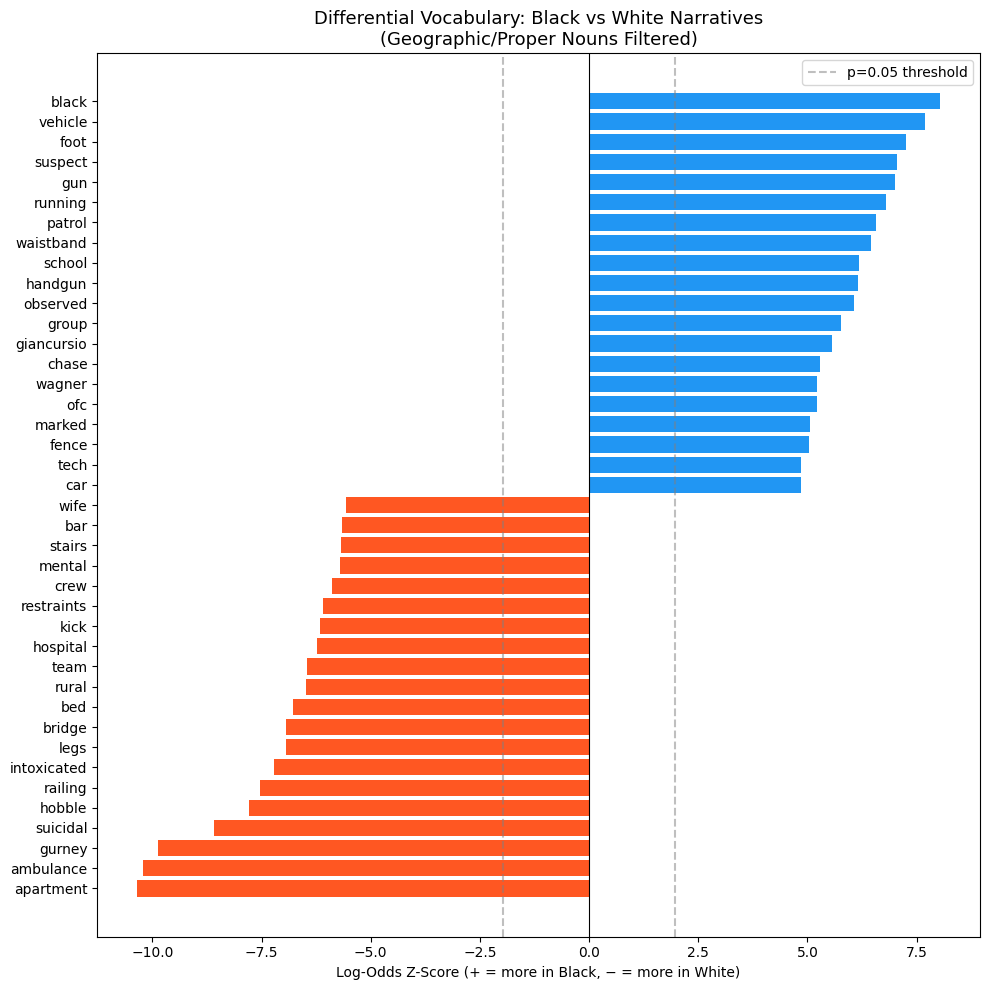

Figure saved.


In [7]:
# Visualization: diverging bar chart
n_show = 20
top_b = lo_df.nlargest(n_show, 'z_score')
top_w = lo_df.nsmallest(n_show, 'z_score')
plot_df = pd.concat([top_b, top_w]).sort_values('z_score')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#FF5722' if z < 0 else '#2196F3' for z in plot_df['z_score']]
ax.barh(plot_df['word'], plot_df['z_score'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log-Odds Z-Score (+ = more in Black, − = more in White)')
ax.set_title('Differential Vocabulary: Black vs White Narratives\n(Geographic/Proper Nouns Filtered)', fontsize=13)
ax.axvline(1.96, color='gray', linestyle='--', alpha=0.5, label='p=0.05 threshold')
ax.axvline(-1.96, color='gray', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/01_log_odds_fixed.png', dpi=150)
plt.show()
print('Figure saved.')

## 4. FastText — Load Existing Model + Semantic Analysis

In [8]:
import fasttext
import os

# Load pre-trained model (from pipeline v1) or retrain
if os.path.exists(config.FASTTEXT_MODEL):
    print('Loading existing FastText model...')
    ft_model = fasttext.load_model(config.FASTTEXT_MODEL)
    print(f'Vocab size: {len(ft_model.words)}')
else:
    print('Training FastText model...')
    # Write training corpus
    train_file = f'{config.OUTPUTS_DIR}/ft_train.txt'
    with open(train_file, 'w') as f:
        for text in df[nar_col].fillna(''):
            tokens = tokenize(text, stopwords=None)  # no stopwords for embeddings
            if len(tokens) > 5:
                f.write(' '.join(tokens) + '\n')
    ft_model = fasttext.train_unsupervised(
        train_file, model='skipgram', dim=100, epoch=15, minCount=3, thread=4
    )
    ft_model.save_model(config.FASTTEXT_MODEL)
    print(f'Trained. Vocab: {len(ft_model.words)}')

Loading existing FastText model...
Vocab size: 5992


In [9]:
def nearest_neighbors(model, word, n=10):
    """Get nearest neighbors for a word."""
    try:
        neighbors = model.get_nearest_neighbors(word, k=n)
        return [(sim, w) for sim, w in neighbors]
    except:
        return []

# Key semantic probes
probe_words = [
    'compliant', 'cooperative', 'calm', 'aggressive', 'resisting',
    'fleeing', 'threatening', 'passive', 'combative', 'uncooperative'
]

print('FastText Nearest Neighbors (semantic space structure):')
print('='*60)
for word in probe_words:
    if word in ft_model.words:
        nbrs = nearest_neighbors(ft_model, word, n=5)
        print(f'\n"{word}":')
        for sim, w in nbrs:
            print(f'  {sim:.3f}  {w}')
    else:
        print(f'\n"{word}": NOT IN VOCAB')

FastText Nearest Neighbors (semantic space structure):

"compliant":
  0.816  noncompliant
  0.591  noncompliance
  0.582  irritated
  0.568  compliance
  0.554  non

"cooperative":
  0.844  uncooperative
  0.818  cooperation
  0.780  cooperating
  0.761  cooperate
  0.757  cooperated

"calm":
  0.757  calmly
  0.705  relax
  0.669  calming
  0.569  calmed
  0.563  ssos

"aggressive":
  0.813  aggressively
  0.708  aggression
  0.698  agitated
  0.657  irritated
  0.637  combative

"resisting":
  0.802  resisiting
  0.801  resisitng
  0.786  resist
  0.677  resisted
  0.661  actively

"fleeing":
  0.644  flee
  0.633  foot
  0.605  freeing
  0.598  broadcasting
  0.598  seeing

"threatening":
  0.834  threatened
  0.822  threaten
  0.760  threats
  0.726  threating
  0.658  threat

"passive":
  0.793  passively
  0.660  resistive
  0.656  deadweight
  0.648  abusive
  0.608  dead

"combative":
  0.676  combat
  0.637  aggressive
  0.632  belligerent
  0.621  beligerent
  0.600  sedativ

In [10]:
# Encode all narratives to document vectors
def encode_narrative(model, text, stopwords=None):
    tokens = tokenize(text, stopwords=stopwords)
    if not tokens:
        return np.zeros(model.get_dimension())
    vecs = [model.get_word_vector(t) for t in tokens]
    return np.mean(vecs, axis=0)

print('Encoding narratives...')
embeddings = np.array([
    encode_narrative(ft_model, text)
    for text in df[nar_col].fillna('')
])
print(f'Embeddings shape: {embeddings.shape}')

Encoding narratives...
Embeddings shape: (2656, 100)


## 5. UMAP + K-Means Clustering

In [11]:
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from scipy.stats import chi2_contingency

np.random.seed(config.RANDOM_SEED)

# Normalize embeddings
emb_norm = normalize(embeddings)

# UMAP
print('Running UMAP...')
reducer = UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric='cosine',
               random_state=config.RANDOM_SEED)
umap_2d = reducer.fit_transform(emb_norm)
print(f'UMAP complete: {umap_2d.shape}')

# K-Means with k=6
k = 6
km = KMeans(n_clusters=k, n_init=20, random_state=config.RANDOM_SEED)
clusters = km.fit_predict(emb_norm)
df['cluster'] = clusters
df['umap_x'] = umap_2d[:,0]
df['umap_y'] = umap_2d[:,1]

# Chi-square test: cluster × race
ct = pd.crosstab(df['cluster'], df['race'])
chi2, p, dof, _ = chi2_contingency(ct)
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f'\nCluster × Race: chi2={chi2:.2f}, p={p:.4f}, Cramér\'s V={cramers_v:.4f}')
print(ct)

Running UMAP...
UMAP complete: (2656, 2)

Cluster × Race: chi2=65.15, p=0.0000, Cramér's V=0.1566
race     Black  White
cluster              
0          392     67
1          367    200
2          602    190
3           80     28
4          194     71
5          317    148


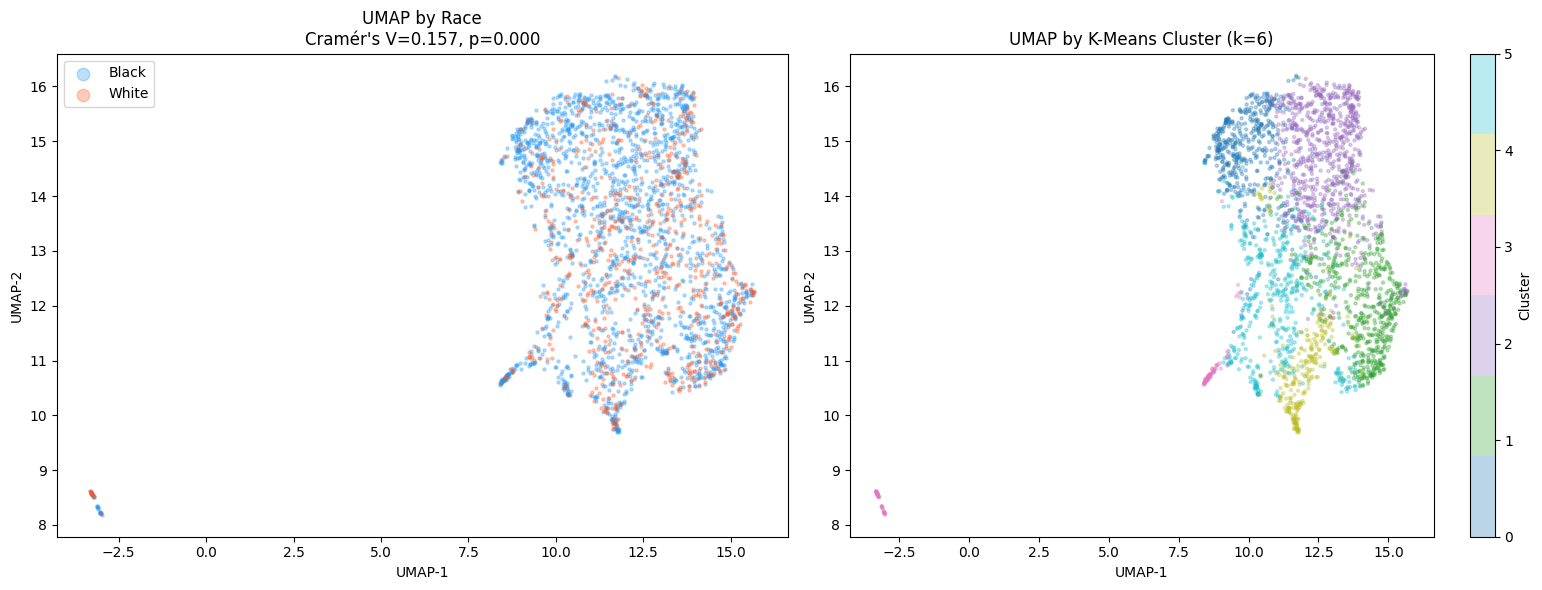

Figure saved.


In [12]:
# Visualize UMAP colored by race and by cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By race
race_colors = {'Black': '#2196F3', 'White': '#FF5722'}
for race, grp in df.groupby('race'):
    axes[0].scatter(grp['umap_x'], grp['umap_y'], c=race_colors.get(race, 'gray'),
                    alpha=0.3, s=5, label=race)
axes[0].set_title(f'UMAP by Race\nCramér\'s V={cramers_v:.3f}, p={p:.3f}')
axes[0].legend(markerscale=4)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# By cluster
cmap = cm.get_cmap('tab10', k)
scatter = axes[1].scatter(df['umap_x'], df['umap_y'], c=df['cluster'],
                           cmap=cmap, alpha=0.3, s=5)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_title(f'UMAP by K-Means Cluster (k={k})')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

plt.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/01_umap_clustering.png', dpi=150)
plt.show()
print('Figure saved.')

In [13]:
# Per-cluster race composition
cluster_race = df.groupby('cluster')['race'].value_counts(normalize=True).unstack().fillna(0)
print('Race composition per cluster (%):')
print((cluster_race * 100).round(1))

# Top differential terms per cluster (via log-odds vs all others)
print('\nTop terms per cluster (vs rest):')
for c in range(k):
    in_cluster  = df[df['cluster']==c][nar_col].fillna('').apply(lambda t: tokenize(t, ALL_STOPWORDS)).tolist()
    out_cluster = df[df['cluster']!=c][nar_col].fillna('').apply(lambda t: tokenize(t, ALL_STOPWORDS)).tolist()
    lo = monroe_log_odds(in_cluster, out_cluster, min_count=3)
    top5 = lo.nlargest(5, 'z_score')['word'].tolist()
    pct_black = cluster_race.loc[c, 'Black'] * 100 if 'Black' in cluster_race.columns else 0
    print(f'  Cluster {c} ({pct_black:.0f}% Black): {top5}')

Race composition per cluster (%):
race     Black  White
cluster              
0         85.4   14.6
1         64.7   35.3
2         76.0   24.0
3         74.1   25.9
4         73.2   26.8
5         68.2   31.8

Top terms per cluster (vs rest):
  Cluster 0 (85% Black): ['running', 'suspect', 'fence', 'foot', 'male']
  Cluster 1 (65% Black): ['gurney', 'ambulance', 'hospital', 'staff', 'legs']
  Cluster 2 (76% Black): ['subject', 'officer', 'right', 'left', 'arm']
  Cluster 3 (74% Black): ['group', 'crowd', 'disperse', 'large', 'people']
  Cluster 4 (73% Black): ['car', 'door', 'window', 'rear', 'patrol']
  Cluster 5 (68% Black): ['school', 'redacted', 'leave', 'fight', 'location']
